# Best-results figures

Loads precomputed best curves from `best_results_*.csv` (exported by `graphs_finetune.ipynb`) and plots mean curves with saved error bands.

**Layout:** one figure per **granularity** (binary / ternary / continuous); **subplots** = tasks; **lines** = neural conditions at each task's best (noise, β, ft).


In [27]:
import json
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.4,
})


In [28]:
BEST_RESULTS_FILE = Path("lunar_best_results.csv")

METRIC_LABELS = {
    "results_success_rate": "Evaluation success rate",
    "results_total_reward": "Mean evaluation return",
    "results_steps": "Steps at evaluation",
}
ERROR_BAND_LABELS = {
    "sem": "± SEM",
    "std": "± STD",
    "ci95": "95% CI",
    "ci99": "99% CI",
}

TASK_ORDER = ["Passive", "Active", "Pooled"]
CONDITION_ORDER = [
    "Baseline-PER",
    "Prioritization-PER",
    "Q-Augmentation-PER",
    "Reward Augmentation-PER",
    "All-PER",
]
ABLATION_CONDITION = "Baseline-PER"

GRANULARITIES_TO_PLOT = ["binary", "ternary", "continuous"]
GRANULARITY_ORDER = GRANULARITIES_TO_PLOT
GRANULARITY_LINE_STYLES = {
    "binary": "-",
    "ternary": "--",
    "continuous": ":",
}
TASKS_TO_PLOT = TASK_ORDER
KEEP_LATEST_DUPLICATES = True

PLOT_START_IDX = 0
PLOT_END_IDX = None  # None → use min checkpoint length across conditions in each task
# Optional per-task caps applied after min-length alignment
PLOT_END_IDX_BY_TASK = {
    "Passive": 200,
    "Pooled": 200,
    "Active": 200,
}

# Summary metrics (computed per-seed when seed_means are available)
SUMMARY_METRICS = ["terminal", "steps_to_threshold"]  # order of tables to display
BASELINE_PEAK_FRACTION = 0.9
FINAL_WINDOW = 20  # checkpoints for terminal success
SUMMARY_ALPHA = 0.05
AUC_ALPHA = SUMMARY_ALPHA  # alias
TRUNCATE_TO_MIN_LENGTH = True  # cut all curves to shortest trial in each task × granularity

SAVE_FIGURES = False
FIGURES_DIR = Path("figures_best_results")
FIG_WIDTH_IN = 9.0
FIG_HEIGHT_IN = 4.0
ERROR_BAND_ALPHA = 0.15

LINE_COLORS  = [
    "#b85454",  # Muted Brick Red
    "#d99b43",  # Muted Amber Orange
    "#668f67",  # Muted Olive Green
    "#467ca3",  # Muted Steel Blue
    "#7e6294"   # Muted Dusty Purple
]
CONDITION_COLORS = {
    "Baseline-PER": "#b85454",
    "Prioritization-PER": "#d99b43",
    "Q-Augmentation-PER": "#668f67",
    "Reward Augmentation-PER": "#467ca3",
    "All-PER": "#7e6294",
}


In [29]:
def load_best_results(path: Path | str = BEST_RESULTS_FILE) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)
    array_cols = ["mean", "std", "sem", "band_halfwidth"]
    for col in array_cols:
        if col in df.columns:
            df[col] = df[col].apply(json.loads)

    if "seed_means" in df.columns:
        def _parse_seed_means(v):
            if v is None or (isinstance(v, float) and np.isnan(v)):
                return []
            if isinstance(v, str):
                parsed = json.loads(v)
            else:
                parsed = v
            return [np.asarray(s, dtype=float) for s in parsed]
        df["seed_means"] = df["seed_means"].apply(_parse_seed_means)
    else:
        df["seed_means"] = [[] for _ in range(len(df))]

    if KEEP_LATEST_DUPLICATES and "saved_at" in df.columns:
        df = (
            df.sort_values("saved_at")
            .drop_duplicates(["granularity", "task", "condition"], keep="last")
            .reset_index(drop=True)
        )

    return df


def align_group_to_min_length(sub: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """Truncate mean/std/sem/band/seed curves to the shortest checkpoint length in the group."""
    if sub.empty:
        return sub, 0
    lengths = [len(np.asarray(m)) for m in sub["mean"]]
    min_len = int(min(lengths)) if lengths else 0
    if min_len <= 0:
        return sub.copy(), 0

    out = sub.copy()
    for col in ["mean", "std", "sem", "band_halfwidth"]:
        if col in out.columns:
            out[col] = out[col].apply(lambda arr: np.asarray(arr, dtype=float)[:min_len])
    if "seed_means" in out.columns:
        out["seed_means"] = out["seed_means"].apply(
            lambda seeds: [np.asarray(s, dtype=float)[:min_len] for s in (seeds or [])]
        )
    out["checkpoint_count"] = min_len
    return out, min_len


def align_best_results_to_min_length(df: pd.DataFrame) -> pd.DataFrame:
    """Within each task × granularity, cut all conditions to the shortest trial length."""
    if not TRUNCATE_TO_MIN_LENGTH or df.empty:
        return df
    parts = []
    for (_, _), grp in df.groupby(["task", "granularity"], sort=False):
        aligned, min_len = align_group_to_min_length(grp)
        parts.append(aligned)
        tasks = grp["task"].iloc[0]
        gran = grp["granularity"].iloc[0]
        before = sorted({len(np.asarray(m)) for m in grp["mean"]})
        if len(before) > 1 or (before and before[0] != min_len):
            print(f"Aligned {tasks}/{gran}: lengths {before} → {min_len}")
    return pd.concat(parts, ignore_index=True)


best = load_best_results()
best = align_best_results_to_min_length(best)
n_with_seeds = int((best["seed_means"].map(len) > 0).sum()) if "seed_means" in best.columns else 0
print(f"Loaded {len(best)} rows from {BEST_RESULTS_FILE.resolve()}")
print(f"Rows with per-seed curves: {n_with_seeds}/{len(best)}")
if n_with_seeds == 0:
    print("Note: re-export from graphs_finetune.ipynb to include seed_means for true per-seed stats.")
best[["granularity", "task", "condition", "noise", "beta", "ft", "error_band", "n_seeds", "checkpoint_count"]].head()


Aligned Passive/continuous: lengths [152, 160, 166, 168, 178] → 152
Aligned Pooled/continuous: lengths [170, 173, 177, 182, 184] → 170
Aligned Active/continuous: lengths [155, 156, 158, 160, 164] → 155
Aligned Active/binary: lengths [134, 152, 156, 164, 165] → 134
Aligned Pooled/binary: lengths [168, 170, 177, 178, 181] → 168
Aligned Passive/binary: lengths [163, 165, 168, 173, 175] → 163
Aligned Pooled/ternary: lengths [154, 170, 171, 179, 182] → 154
Aligned Active/ternary: lengths [156, 157, 158, 160, 163] → 156
Aligned Passive/ternary: lengths [160, 168, 169] → 160
Loaded 45 rows from /Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/lunar_best_results.csv
Rows with per-seed curves: 45/45


,granularity,task,condition,noise,beta,ft,error_band,n_seeds,checkpoint_count
0,continuous,Passive,Baseline-PER,0.0,1.0,0.0,sem,10,152
1,continuous,Passive,All-PER,0.0,0.5,0.0,sem,10,152
2,continuous,Passive,Reward Augmentation-PER,0.0,0.5,0.0,sem,10,152
3,continuous,Passive,Q-Augmentation-PER,0.0,0.5,0.0,sem,10,152
4,continuous,Passive,Prioritization-PER,0.0,0.5,0.0,sem,10,152


In [30]:
_TITLE_SMALL = {"a", "an", "the", "and", "or", "but", "in", "on", "at", "to", "for", "of", "with", "per", "by", "across"}


def title_case(text: str) -> str:
    words = re.split(r"(\s+)", str(text).strip())
    out = []
    for i, w in enumerate(words):
        if not w.strip():
            out.append(w)
            continue
        core = w.lower()
        if i > 0 and i < len(words) - 1 and core in _TITLE_SMALL:
            out.append(core)
        else:
            out.append(core[:1].upper() + core[1:])
    return "".join(out)


def format_condition(condition: str) -> str:
    """Legend/title label: drop -PER/-ER suffix, then title-case."""
    text = str(condition)
    for suffix in ("-PER", "-ER"):
        if text.endswith(suffix):
            text = text[: -len(suffix)]
            break
    return title_case(text.replace("-", " "))


def format_n_seeds(n_seeds_list: list) -> str:
    vals = sorted({int(n) for n in n_seeds_list})
    if len(vals) == 1:
        return f"n = {vals[0]}"
    return f"n = {min(vals)}–{max(vals)}"


def ablation_line_label(ablation_kind: str, value) -> str:
    if ablation_kind == "noise":
        return f"Noise = {value:g}" if isinstance(value, (int, float)) else f"Noise = {value}"
    if ablation_kind == "beta":
        return f"β = {value:g}" if isinstance(value, (int, float)) else f"β = {value}"
    if ablation_kind in ("ft", "ff"):
        return f"Ft = {value:g}" if isinstance(value, (int, float)) else f"Ft = {value}"
    return str(value)


def format_best_setting_label(row) -> str:
    return (
        f"{format_condition(row['condition'])}\n"
        f"{ablation_line_label('noise', row['noise'])}, "
        f"{ablation_line_label('beta', row['beta'])}, "
        f"{ablation_line_label('ft', row['ft'])}"
    )


def resolve_plot_color(index: int, label: str) -> str:
    if label in CONDITION_COLORS:
        return CONDITION_COLORS[label]
    return LINE_COLORS[index % len(LINE_COLORS)]


def slice_plot_range(arr, start_idx=None, end_idx=None):
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    start = 0 if start_idx is None else int(start_idx)
    end = n if end_idx is None else int(end_idx)
    start = max(0, min(start, n))
    end = max(start, min(end, n))
    return arr[start:end], start, end


def _is_baseline_condition(name) -> bool:
    return str(name) == ABLATION_CONDITION


def _is_baseline_legend_label(text: str) -> bool:
    return text.startswith(format_condition(ABLATION_CONDITION))


def _condition_line_order(conditions: list) -> list[int]:
    return sorted(range(len(conditions)), key=lambda i: (1 if _is_baseline_condition(conditions[i]) else 0, i))


def _subplot_figsize(nrows: int, ncols: int) -> tuple[float, float]:
    return (FIG_WIDTH_IN * ncols / 2, FIG_HEIGHT_IN * nrows)


def _emphasize_baseline(ax) -> None:
    for line in ax.get_lines():
        if _is_baseline_legend_label(line.get_label()):
            line.set_zorder(10)
            line.set_linewidth(mpl.rcParams["lines.linewidth"] * 1.25)
    for coll in ax.collections:
        label = coll.get_label()
        if label and _is_baseline_legend_label(label):
            coll.set_zorder(9)


def _legend_baseline_first(ax) -> None:
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    order = sorted(range(len(labels)), key=lambda i: (0 if _is_baseline_legend_label(labels[i]) else 1, i))
    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        frameon=True,
        framealpha=0.92,
        edgecolor="#cccccc",
        fancybox=False,
        loc="lower right",
        handlelength=2.0,
        borderpad=0.4,
        labelspacing=0.3,
    )


def format_subplot_title(task: str, *, band_label: str, n_seeds_list: list) -> str:
    meta = f"{band_label} · {format_n_seeds(n_seeds_list)}".strip(" ·")
    return f"{title_case(task)}\n{meta}" if meta else title_case(task)


def _save_fig(fig, filename: str):
    if SAVE_FIGURES and filename:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        stem = Path(filename).stem
        for ext in (".pdf", ".png"):
            out = FIGURES_DIR / f"{stem}{ext}"
            fig.savefig(out, dpi=mpl.rcParams["savefig.dpi"], bbox_inches="tight", pad_inches=0.02)
            print(f"Saved {out}")


def plot_saved_mean_band(
    ax,
    mean,
    band,
    *,
    label,
    color,
    linestyle="-",
    linewidth=None,
    start_idx=None,
    end_idx=None,
    zorder=3,
):
    mean, start, end = slice_plot_range(mean, start_idx, end_idx)
    band, _, _ = slice_plot_range(band, start_idx, end_idx)
    if len(mean) == 0:
        return False

    x = np.arange(start, end)
    markevery = max(len(x) // 8, 1)
    ax.plot(
        x,
        mean,
        label=label,
        color=color,
        linestyle=linestyle,
        zorder=zorder,
        linewidth=mpl.rcParams["lines.linewidth"],
        marker="o",
        markevery=markevery,
        markersize=mpl.rcParams["lines.markersize"],
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.4,
    )
    if np.any(np.isfinite(band)) and np.nanmax(band) > 0:
        ax.fill_between(
            x,
            mean - band,
            mean + band,
            color=color,
            alpha=ERROR_BAND_ALPHA,
            linewidth=0,
            zorder=zorder - 1,
        )
    return True


def _apply_ax_style(ax, *, metric: str, show_ylabel: bool = True, show_xlabel: bool = True, show_legend: bool = True):
    if show_xlabel:
        ax.set_xlabel("Evaluation Checkpoint", labelpad=2)
    else:
        ax.set_xlabel("")
    if show_ylabel:
        ax.set_ylabel(METRIC_LABELS.get(metric, metric), labelpad=2)
    else:
        ax.set_ylabel("")
    _emphasize_baseline(ax)
    if show_legend:
        _legend_baseline_first(ax)
    if metric == "results_success_rate":
        ax.set_ylim(bottom=-0.02, top=1.02)
        ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.set_xlim(left=0)
    ax.tick_params(which="both", top=False, right=False)
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2g"))


def _add_comparison_legends(ax) -> None:
    """Separate legends for condition (color) and granularity (linestyle)."""
    from matplotlib.lines import Line2D

    condition_handles = [
        Line2D(
            [0], [0],
            color=CONDITION_COLORS.get(condition, LINE_COLORS[i % len(LINE_COLORS)]),
            linewidth=mpl.rcParams["lines.linewidth"] * (1.25 if _is_baseline_condition(condition) else 1.0),
            label=format_condition(condition),
        )
        for i, condition in enumerate(CONDITION_ORDER)
        if condition in CONDITION_COLORS
    ]
    granularity_handles = [
        Line2D(
            [0], [0],
            color="#444444",
            linestyle=GRANULARITY_LINE_STYLES.get(granularity, "-"),
            linewidth=mpl.rcParams["lines.linewidth"],
            label=title_case(granularity),
        )
        for granularity in GRANULARITY_ORDER
        if granularity in GRANULARITY_LINE_STYLES
    ]

    leg_cond = ax.legend(
        handles=condition_handles,
        title="Condition",
        frameon=True,
        framealpha=0.92,
        edgecolor="#cccccc",
        fancybox=False,
        loc="lower right",
        bbox_to_anchor=(1.0, 0.0),
        handlelength=2.0,
        borderpad=0.4,
        labelspacing=0.3,
    )
    ax.add_artist(leg_cond)
    ax.legend(
        handles=granularity_handles,
        title="Granularity",
        frameon=True,
        framealpha=0.92,
        edgecolor="#cccccc",
        fancybox=False,
        loc="lower right",
        bbox_to_anchor=(1.0, 0.38),
        handlelength=2.0,
        borderpad=0.4,
        labelspacing=0.3,
    )


def resolve_plot_end_idx(task: str, end_idx: int | None = None) -> int | None:
    """Use per-task override when set; else the global end_idx."""
    overrides = globals().get("PLOT_END_IDX_BY_TASK", {})
    if task in overrides:
        return overrides[task]
    return end_idx


def _trapz_weights(n: int) -> np.ndarray:
    w = np.ones(n, dtype=float)
    if n >= 2:
        w[0] = 0.5
        w[-1] = 0.5
    return w


def curve_auc(mean, *, start_idx=None, end_idx=None) -> float:
    """Trapezoidal AUC of the mean curve, normalized by number of checkpoints."""
    y, _, _ = slice_plot_range(mean, start_idx, end_idx)
    if len(y) == 0:
        return float("nan")
    auc = float(np.trapezoid(y) if hasattr(np, "trapezoid") else np.trapz(y))
    return auc / len(y)


def curve_auc_std(std, *, start_idx=None, end_idx=None) -> float:
    """Approx. across-seed SD of normalized AUC (independent-checkpoint approx)."""
    s, _, _ = slice_plot_range(std, start_idx, end_idx)
    if len(s) == 0:
        return float("nan")
    w = _trapz_weights(len(s))
    return float(np.sqrt(np.sum((w * np.asarray(s, dtype=float)) ** 2)) / len(s))


def curve_peak(mean, *, start_idx=None, end_idx=None) -> float:
    """Peak success rate of the curve within the plot window."""
    y, _, _ = slice_plot_range(mean, start_idx, end_idx)
    if len(y) == 0:
        return float("nan")
    return float(np.nanmax(np.asarray(y, dtype=float)))


def curve_terminal(mean, *, start_idx=None, end_idx=None, window: int = FINAL_WINDOW) -> float:
    """Mean success over the last `window` checkpoints of the sliced curve."""
    y, _, _ = slice_plot_range(mean, start_idx, end_idx)
    if len(y) == 0:
        return float("nan")
    k = min(int(window), len(y))
    return float(np.nanmean(y[-k:]))


def curve_steps_to_threshold(
    mean,
    *,
    threshold: float,
    start_idx=None,
    end_idx=None,
) -> float:
    """First evaluation checkpoint where success reaches `threshold` (NaN if never)."""
    y, start, _ = slice_plot_range(mean, start_idx, end_idx)
    if len(y) == 0:
        return float("nan")
    hits = np.where(np.asarray(y, dtype=float) >= threshold)[0]
    if len(hits) == 0:
        return float("nan")
    return float(start + hits[0])


def baseline_peak_threshold(
    baseline_row,
    *,
    fraction: float = BASELINE_PEAK_FRACTION,
    start_idx=None,
    end_idx=None,
) -> tuple[float, float]:
    """Return (threshold, baseline_peak) where threshold = fraction × baseline peak."""
    peak = curve_peak(baseline_row["mean"], start_idx=start_idx, end_idx=end_idx)
    if not np.isfinite(peak) or peak <= 0:
        return float("nan"), peak
    return float(fraction * peak), peak


def _seed_curves(row) -> list[np.ndarray]:
    seeds = row.get("seed_means", None)
    if seeds is None:
        return []
    out = []
    for s in seeds:
        arr = np.asarray(s, dtype=float)
        if len(arr):
            out.append(arr)
    return out


def per_seed_metric_values(
    row,
    metric: str,
    *,
    start_idx=None,
    end_idx=None,
    threshold: float | None = None,
    window: int = FINAL_WINDOW,
) -> np.ndarray:
    """Compute metric on each seed curve; empty if seed_means unavailable."""
    seeds = _seed_curves(row)
    if not seeds:
        return np.array([], dtype=float)

    values = []
    for s in seeds:
        if metric == "terminal":
            values.append(curve_terminal(s, start_idx=start_idx, end_idx=end_idx, window=window))
        elif metric == "steps_to_threshold":
            if threshold is None or not np.isfinite(threshold):
                values.append(float("nan"))
            else:
                values.append(
                    curve_steps_to_threshold(
                        s, threshold=threshold, start_idx=start_idx, end_idx=end_idx,
                    )
                )
        elif metric == "auc":
            values.append(curve_auc(s, start_idx=start_idx, end_idx=end_idx))
        else:
            raise ValueError(f"Unknown summary metric: {metric!r}")
    return np.asarray(values, dtype=float)


def compute_summary_metric(
    row,
    metric: str,
    *,
    start_idx=None,
    end_idx=None,
    threshold: float | None = None,
    window: int = FINAL_WINDOW,
) -> tuple[float, float, int, bool]:
    """Return (mean, std, n, used_per_seed) for the chosen summary metric."""
    seed_vals = per_seed_metric_values(
        row, metric, start_idx=start_idx, end_idx=end_idx, threshold=threshold, window=window,
    )
    finite = seed_vals[np.isfinite(seed_vals)] if len(seed_vals) else np.array([])
    if len(finite) >= 1:
        return float(np.mean(finite)), float(np.std(finite, ddof=1) if len(finite) > 1 else 0.0), int(len(finite)), True

    # Fallback: metric on aggregated mean curve (± approx from std curve)
    if metric == "terminal":
        value = curve_terminal(row["mean"], start_idx=start_idx, end_idx=end_idx, window=window)
        y, _, _ = slice_plot_range(row["mean"], start_idx, end_idx)
        s, _, _ = slice_plot_range(row["std"], start_idx, end_idx)
        k = min(int(window), len(y)) if len(y) else 0
        value_std = float(np.nanmean(s[-k:])) if k else float("nan")
        return value, value_std, int(row["n_seeds"]), False
    if metric == "auc":
        return (
            curve_auc(row["mean"], start_idx=start_idx, end_idx=end_idx),
            curve_auc_std(row["std"], start_idx=start_idx, end_idx=end_idx),
            int(row["n_seeds"]),
            False,
        )
    if metric == "steps_to_threshold":
        if threshold is None or not np.isfinite(threshold):
            return float("nan"), float("nan"), int(row["n_seeds"]), False
        value = curve_steps_to_threshold(
            row["mean"], threshold=threshold, start_idx=start_idx, end_idx=end_idx,
        )
        # Delta-method approx when seeds unavailable
        y, start, _ = slice_plot_range(row["mean"], start_idx, end_idx)
        s, _, _ = slice_plot_range(row["std"], start_idx, end_idx)
        y = np.asarray(y, dtype=float)
        s = np.asarray(s, dtype=float)
        hits = np.where(y >= threshold)[0] if len(y) else np.array([])
        if len(hits) == 0:
            return value, float("nan"), int(row["n_seeds"]), False
        i = int(hits[0])
        slope = (y[1] - y[0]) if i == 0 and len(y) > 1 else (y[i] - y[i - 1] if i > 0 else 1.0)
        slope = max(abs(float(slope)), 1e-6)
        return value, float(s[i] / slope), int(row["n_seeds"]), False
    raise ValueError(f"Unknown summary metric: {metric!r}")


def welch_ttest_pvalue(
    mean1, std1, n1, mean2, std2, n2, *, alternative: str = "greater",
) -> tuple[float, float]:
    """Welch t-test; alternative 'greater' (mean1>mean2) or 'less' (mean1<mean2)."""
    n1, n2 = int(n1), int(n2)
    if n1 < 2 or n2 < 2:
        return float("nan"), float("nan")
    v1 = float(std1) ** 2
    v2 = float(std2) ** 2
    se2 = v1 / n1 + v2 / n2
    if se2 <= 0 or not np.isfinite(se2):
        return float("nan"), float("nan")
    t_stat = (float(mean1) - float(mean2)) / np.sqrt(se2)
    num = se2 ** 2
    den = (v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1)
    df = num / den if den > 0 else float("nan")
    try:
        from scipy import stats as _stats
        if not np.isfinite(df):
            p = float("nan")
        elif alternative == "greater":
            p = float(_stats.t.sf(t_stat, df))
        elif alternative == "less":
            p = float(_stats.t.cdf(t_stat, df))
        else:
            p = float(2 * _stats.t.sf(abs(t_stat), df))
    except Exception:
        import math
        phi = 0.5 * (1.0 + math.erf(t_stat / math.sqrt(2.0)))
        if alternative == "greater":
            p = float(1.0 - phi)
        elif alternative == "less":
            p = float(phi)
        else:
            p = float(2 * min(phi, 1.0 - phi))
    return float(t_stat), p


def significance_label(p: float, alpha: float = SUMMARY_ALPHA) -> str:
    if not np.isfinite(p):
        return "—"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < alpha:
        return "*"
    return "ns"


def _metric_higher_is_better(metric: str) -> bool:
    return metric != "steps_to_threshold"


def build_summary_table(
    table: pd.DataFrame,
    *,
    metric: str | None = None,
    tasks: list | None = None,
    granularities: list | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
    peak_fraction: float = BASELINE_PEAK_FRACTION,
    window: int = FINAL_WINDOW,
    alpha: float = SUMMARY_ALPHA,
    baseline: str = ABLATION_CONDITION,
) -> pd.DataFrame:
    """Per task × granularity × condition metric ± SD, with two-sided Welch p vs baseline.

    metric:
      - "terminal": mean of last FINAL_WINDOW checkpoints (per-seed when available)
      - "steps_to_threshold": checkpoints until ≥ (peak_fraction × baseline peak)
      - "auc": normalized AUC (legacy)

    Curves should already be aligned to min length via align_best_results_to_min_length.
    """
    metric = metric or SUMMARY_METRICS[0]
    alternative = "two-sided"
    tasks = tasks or [t for t in TASK_ORDER if t in table["task"].values]
    granularities = granularities or [g for g in GRANULARITY_ORDER if g in table["granularity"].values]
    higher_better = _metric_higher_is_better(metric)

    rows = []
    for task in tasks:
        task_end = resolve_plot_end_idx(task, end_idx)
        for granularity in granularities:
            sub = table[(table["task"] == task) & (table["granularity"] == granularity)]
            if sub.empty:
                continue

            baseline_rows = sub[sub["condition"] == baseline]
            if baseline_rows.empty:
                continue
            baseline_row = baseline_rows.iloc[0]
            task_threshold, baseline_peak = baseline_peak_threshold(
                baseline_row,
                fraction=peak_fraction,
                start_idx=start_idx,
                end_idx=task_end,
            )

            by_cond = {}
            for _, r in sub.iterrows():
                value, value_std, n_eff, used_seeds = compute_summary_metric(
                    r,
                    metric,
                    start_idx=start_idx,
                    end_idx=task_end,
                    threshold=task_threshold,
                    window=window,
                )
                by_cond[r["condition"]] = {
                    "value": value,
                    "value_std": value_std,
                    "n_seeds": n_eff,
                    "per_seed": used_seeds,
                    "noise": float(r["noise"]),
                    "beta": float(r["beta"]),
                    "ft": float(r["ft"]),
                    "checkpoint_count": int(len(np.asarray(r["mean"]))),
                }

            base = by_cond.get(baseline)
            for condition in CONDITION_ORDER:
                if condition not in by_cond:
                    continue
                info = by_cond[condition]
                if condition == baseline or base is None:
                    t_stat, p_val = float("nan"), float("nan")
                    sig = "—"
                    significant = False
                    better = False
                else:
                    t_stat, p_val = welch_ttest_pvalue(
                        info["value"], info["value_std"], info["n_seeds"],
                        base["value"], base["value_std"], base["n_seeds"],
                        alternative=alternative,
                    )
                    if higher_better:
                        better = (
                            np.isfinite(info["value"])
                            and np.isfinite(base["value"])
                            and info["value"] > base["value"]
                        )
                    else:
                        better = (
                            np.isfinite(info["value"])
                            and np.isfinite(base["value"])
                            and info["value"] < base["value"]
                        )
                    sig = significance_label(p_val, alpha=alpha) if better else "ns"
                    significant = bool(
                        better and np.isfinite(p_val) and p_val < alpha
                    )

                rows.append({
                    "task": task,
                    "granularity": granularity,
                    "condition": condition,
                    "metric": metric,
                    "per_seed": info["per_seed"],
                    "baseline_peak": baseline_peak if metric == "steps_to_threshold" else np.nan,
                    "threshold_fraction": peak_fraction if metric == "steps_to_threshold" else np.nan,
                    "threshold": task_threshold if metric == "steps_to_threshold" else np.nan,
                    "final_window": window if metric == "terminal" else np.nan,
                    "noise": info["noise"],
                    "beta": info["beta"],
                    "ft": info["ft"],
                    "n_seeds": info["n_seeds"],
                    "end_idx": task_end if task_end is not None else info["checkpoint_count"],
                    "checkpoint_count": info["checkpoint_count"],
                    "value": info["value"],
                    "value_std": info["value_std"],
                    "t_vs_baseline": t_stat,
                    "p_vs_baseline": p_val,
                    "significant": significant,
                    "sig": sig,
                })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    task_rank = {t: i for i, t in enumerate(TASK_ORDER)}
    gran_rank = {g: i for i, g in enumerate(GRANULARITY_ORDER)}
    cond_rank = {c: i for i, c in enumerate(CONDITION_ORDER)}
    out["_t"] = out["task"].map(task_rank)
    out["_g"] = out["granularity"].map(gran_rank)
    out["_c"] = out["condition"].map(cond_rank)
    return (
        out.sort_values(["_t", "_g", "_c"])
        .drop(columns=["_t", "_g", "_c"])
        .reset_index(drop=True)
    )


def format_summary_table(summary_df: pd.DataFrame) -> pd.DataFrame:
    """Readable display columns for the summary metric table."""
    if summary_df.empty:
        return summary_df
    metric = summary_df["metric"].iloc[0] if "metric" in summary_df.columns else SUMMARY_METRICS[0]
    if metric == "steps_to_threshold":
        frac = summary_df["threshold_fraction"].dropna()
        fraction = float(frac.iloc[0]) if len(frac) else BASELINE_PEAK_FRACTION
        value_col = f"Steps to {fraction:.0%} baseline peak"
    elif metric == "terminal":
        win = summary_df["final_window"].dropna()
        w = int(win.iloc[0]) if len(win) else FINAL_WINDOW
        value_col = f"Terminal (last {w})"
    else:
        value_col = "AUC"

    def _format_value_cell(r):
        if not np.isfinite(r["value"]):
            return "—"
        if metric == "steps_to_threshold":
            thr = r.get("threshold", np.nan)
            base = f"{r['value']:.1f} ± {r['value_std']:.1f}"
            if np.isfinite(thr):
                return f"{base} (target {thr:.2g})"
            return base
        return f"{r['value']:.3f} ± {r['value_std']:.3f}"

    disp = summary_df.copy()
    disp[value_col] = disp.apply(_format_value_cell, axis=1)
    disp["p"] = disp["p_vs_baseline"].map(
        lambda p: "—" if not np.isfinite(p) else (f"{p:.2e}" if p < 1e-3 else f"{p:.3g}")
    )
    hyp = "better than baseline"
    disp[f"sig. ({hyp})"] = disp.apply(
        lambda r: "—" if r["condition"] == ABLATION_CONDITION else (
            f"yes ({r['sig']})" if r["significant"] else f"no ({r['sig']})"
        ),
        axis=1,
    )
    disp["stats"] = disp["per_seed"].map(lambda x: "per-seed" if x else "mean-curve")
    cols = ["task", "granularity", "condition", value_col, "n_seeds", "stats", "p", f"sig. ({hyp})"]
    if metric == "steps_to_threshold" and "baseline_peak" in disp.columns:
        disp["baseline peak"] = disp["baseline_peak"].map(
            lambda v: "—" if not np.isfinite(v) else f"{v:.2g}"
        )
        cols.insert(4, "baseline peak")
    return disp[cols]


def build_auc_table(*args, **kwargs) -> pd.DataFrame:
    """Optional AUC summary (same schema as build_summary_table with metric='auc')."""
    kwargs = dict(kwargs)
    kwargs["metric"] = "auc"
    return build_summary_table(*args, **kwargs)


def format_auc_table(auc_df: pd.DataFrame) -> pd.DataFrame:
    """Readable display for an AUC summary table."""
    return format_summary_table(auc_df)


def plot_best_results_for_task(
    table: pd.DataFrame,
    task: str,
    *,
    granularities: list | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    """One figure per task: all conditions and granularities on the same axes."""
    end_idx = resolve_plot_end_idx(task, end_idx)
    sub = table[table["task"] == task].copy()
    if end_idx is None and len(sub):
        end_idx = int(min(len(np.asarray(m)) for m in sub["mean"]))
    if sub.empty:
        print(f"Skip: no rows for task={task!r}")
        return None

    granularities = granularities or [g for g in GRANULARITY_ORDER if g in sub["granularity"].values]
    if not granularities:
        print(f"Skip: no granularities for task={task!r}")
        return None

    metric = sub["metric"].mode().iloc[0]
    error_band = sub["error_band"].mode().iloc[0]
    band_label = ERROR_BAND_LABELS.get(str(error_band).lower(), error_band)
    n_seeds_list = []

    fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH_IN * 0.75, FIG_HEIGHT_IN))

    plot_order = [
        (condition, granularity)
        for condition in CONDITION_ORDER
        for granularity in granularities
    ]
    plot_order.sort(
        key=lambda pair: (
            1 if _is_baseline_condition(pair[0]) else 0,
            CONDITION_ORDER.index(pair[0]) if pair[0] in CONDITION_ORDER else 99,
            GRANULARITY_ORDER.index(pair[1]) if pair[1] in GRANULARITY_ORDER else 99,
        )
    )

    for condition, granularity in plot_order:
        match = sub[(sub["condition"] == condition) & (sub["granularity"] == granularity)]
        if match.empty:
            continue
        r = match.iloc[0]
        n_seeds_list.append(int(r["n_seeds"]))
        color = resolve_plot_color(CONDITION_ORDER.index(condition), condition)
        linestyle = GRANULARITY_LINE_STYLES.get(granularity, "-")
        zorder = 10 if _is_baseline_condition(condition) else 3
        lw = mpl.rcParams["lines.linewidth"] * (1.25 if _is_baseline_condition(condition) else 1.0)
        plot_saved_mean_band(
            ax,
            r["mean"],
            r["band_halfwidth"],
            label="",
            color=color,
            linestyle=linestyle,
            linewidth=lw,
            start_idx=start_idx,
            end_idx=end_idx,
            zorder=zorder,
        )

    _apply_ax_style(ax, metric=metric, show_legend=False)
    _add_comparison_legends(ax)
    ax.set_title(format_subplot_title(task, band_label=band_label, n_seeds_list=n_seeds_list))
    fig.suptitle(
        f"Best Settings — All Granularities",
        y=1.02,
        fontsize=mpl.rcParams["axes.titlesize"],
    )
    fig.tight_layout()
    _save_fig(fig, f"best_results_{task.lower()}")
    return fig


def plot_all_best_results(
    table: pd.DataFrame,
    *,
    granularities: list | None = None,
    tasks: list | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    """Plot one figure per task with all granularities overlaid."""
    tasks = tasks or [t for t in TASK_ORDER if t in table["task"].values]
    figs = []
    for task in tasks:
        fig = plot_best_results_for_task(
            table,
            task,
            granularities=granularities,
            start_idx=start_idx,
            end_idx=end_idx,
        )
        if fig is not None:
            figs.append(fig)
    return figs


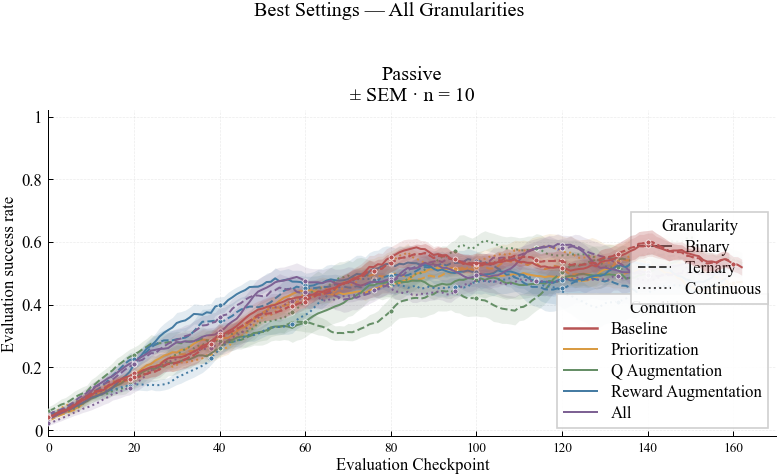

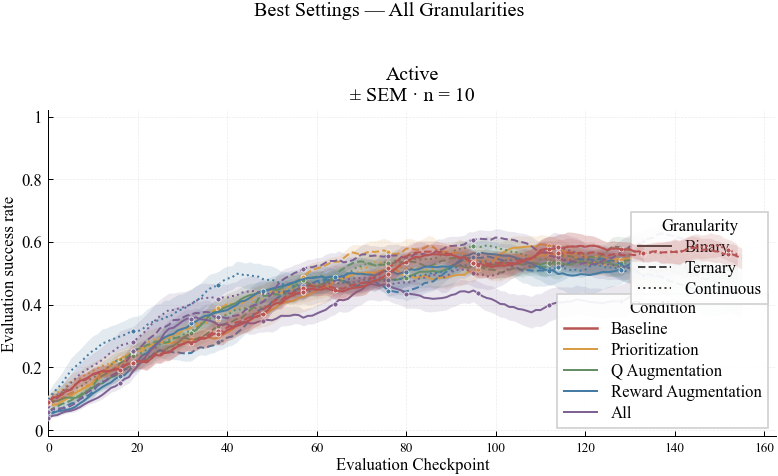

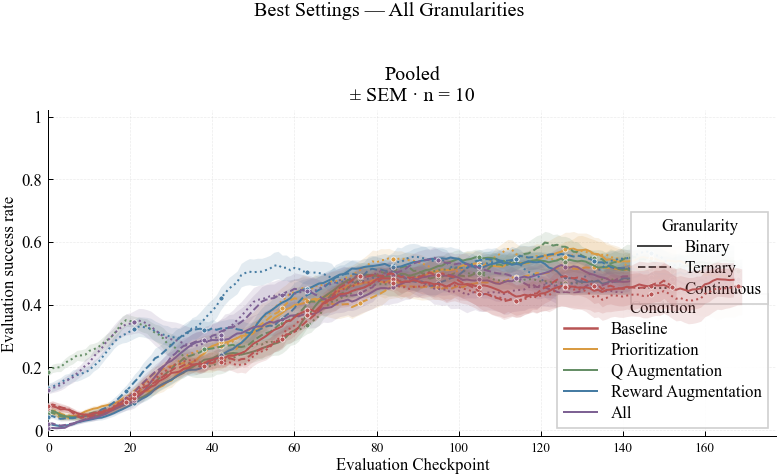

Terminal success last-20 (45 rows; 45 per-seed); two-sided Welch vs Baseline-PER, α=0.05
Stars: * p<0.05, ** p<0.01, *** p<0.001, ns = not significant (or not better than baseline)
Significant only if two-sided p < α AND better than baseline.


,task,granularity,condition,Terminal (last 20),n_seeds,stats,p,sig. (better than baseline)
0,Passive,binary,Baseline-PER,0.552 ± 0.086,10,per-seed,—,—
1,Passive,binary,Prioritization-PER,0.471 ± 0.105,10,per-seed,0.0733,no (ns)
2,Passive,binary,Q-Augmentation-PER,0.548 ± 0.080,10,per-seed,0.906,no (ns)
3,Passive,binary,Reward Augmentation-PER,0.500 ± 0.114,10,per-seed,0.258,no (ns)
4,Passive,binary,All-PER,0.527 ± 0.057,10,per-seed,0.454,no (ns)
5,Passive,ternary,Baseline-PER,0.560 ± 0.086,10,per-seed,—,—
6,Passive,ternary,Prioritization-PER,0.515 ± 0.128,10,per-seed,0.363,no (ns)
7,Passive,ternary,Q-Augmentation-PER,0.538 ± 0.103,10,per-seed,0.61,no (ns)
8,Passive,ternary,Reward Augmentation-PER,0.441 ± 0.162,10,per-seed,0.06,no (ns)
9,Passive,ternary,All-PER,0.497 ± 0.102,10,per-seed,0.15,no (ns)



Steps-to-90%-baseline-peak (45 rows; 45 per-seed); two-sided Welch vs Baseline-PER, α=0.05
Stars: * p<0.05, ** p<0.01, *** p<0.001, ns = not significant (or not better than baseline)
Significant only if two-sided p < α AND better than baseline.


,task,granularity,condition,Steps to 90% baseline peak,baseline peak,n_seeds,stats,p,sig. (better than baseline)
0,Passive,binary,Baseline-PER,72.0 ± 18.1 (target 0.53),0.59,10,per-seed,—,—
1,Passive,binary,Prioritization-PER,86.6 ± 18.0 (target 0.53),0.59,10,per-seed,0.087,no (ns)
2,Passive,binary,Q-Augmentation-PER,103.8 ± 42.9 (target 0.53),0.59,10,per-seed,0.0514,no (ns)
3,Passive,binary,Reward Augmentation-PER,68.2 ± 34.9 (target 0.53),0.59,10,per-seed,0.765,no (ns)
4,Passive,binary,All-PER,79.6 ± 35.3 (target 0.53),0.59,10,per-seed,0.554,no (ns)
5,Passive,ternary,Baseline-PER,74.3 ± 16.4 (target 0.54),0.6,10,per-seed,—,—
6,Passive,ternary,Prioritization-PER,73.6 ± 17.6 (target 0.54),0.6,8,per-seed,0.935,no (ns)
7,Passive,ternary,Q-Augmentation-PER,109.1 ± 29.6 (target 0.54),0.6,10,per-seed,0.00573,no (ns)
8,Passive,ternary,Reward Augmentation-PER,78.4 ± 31.4 (target 0.54),0.6,9,per-seed,0.729,no (ns)
9,Passive,ternary,All-PER,65.9 ± 20.7 (target 0.54),0.6,9,per-seed,0.346,no (ns)


In [31]:
plot_all_best_results(
    best,
    granularities=GRANULARITIES_TO_PLOT,
    tasks=TASKS_TO_PLOT,
    start_idx=PLOT_START_IDX,
    end_idx=PLOT_END_IDX,
)
plt.show()

summary_tables = {}
for metric in SUMMARY_METRICS:
    summary_tables[metric] = build_summary_table(
        best,
        metric=metric,
        tasks=TASKS_TO_PLOT,
        granularities=GRANULARITIES_TO_PLOT,
        start_idx=PLOT_START_IDX,
        end_idx=PLOT_END_IDX,
        peak_fraction=BASELINE_PEAK_FRACTION,
        window=FINAL_WINDOW,
    )
    table = summary_tables[metric]
    per_seed_n = int(table["per_seed"].sum()) if len(table) and "per_seed" in table.columns else 0
    if metric == "steps_to_threshold":
        print(
            f"Steps-to-{BASELINE_PEAK_FRACTION:.0%}-baseline-peak ({len(table)} rows; "
            f"{per_seed_n} per-seed); two-sided Welch vs {ABLATION_CONDITION}, α={SUMMARY_ALPHA}"
        )
    elif metric == "terminal":
        print(
            f"Terminal success last-{FINAL_WINDOW} ({len(table)} rows; "
            f"{per_seed_n} per-seed); two-sided Welch vs {ABLATION_CONDITION}, α={SUMMARY_ALPHA}"
        )
    else:
        print(
            f"{metric} table ({len(table)} rows; {per_seed_n} per-seed); "
            f"two-sided Welch vs {ABLATION_CONDITION}, α={SUMMARY_ALPHA}"
        )
    print("Stars: * p<0.05, ** p<0.01, *** p<0.001, ns = not significant (or not better than baseline)")
    print("Significant only if two-sided p < α AND better than baseline.")
    display(format_summary_table(table))
    print()

# Optional: AUC version
# auc_table = build_auc_table(best, tasks=TASKS_TO_PLOT, granularities=GRANULARITIES_TO_PLOT)
# format_auc_table(auc_table)
